# 🏏 IPL Data Scientist Hiring

<div style="background-color: #1e3a8a; color: white; padding: 20px; border-radius: 10px;">
<h2>Position: Senior Data Scientist - IPL Analytics Team</h2>

<p><b>Dataset:</b> Indian IPL Dataset 2008-2024</p>
<p><b>Submission:</b> Jupyter Notebook with code, visualizations, and insights</p>
</div>

## 📊 Background

The Indian Premier League (IPL) is seeking a talented Data Scientist to join our analytics team. Your role will involve analyzing match data, player performance, fan sentiment, and providing strategic insights to team management.

## 📁 Dataset Information

**Key Columns:**
- `id:` A unique identifier assigned to each IPL match.
- `season:` The year in which the IPL season took place.
- `city`: The city where the match was played.
- `date`: The date on which the match was held.
- `match_type`: Type of the match (e.g., League, Playoff, Final).
- `player_of_match`: The player who was awarded “Player of the Match” for their performance.
- `venue`: The stadium or ground where the match was played.
- `team1`: The first team listed in the fixture.
- `team2`: The second team listed in the fixture.
- `toss_winner`: The team that won the toss before the match began.
- `toss_decision`: The decision made by the toss-winning team—either to bat or to field first.
- `winner`: The team that won the match.
- `result`: The method of victory—either by runs, wickets, or other (e.g., tie, no result).
- `result_margin`: The margin by which the match was won (e.g., number of runs or wickets).
- `target_runs`: The number of runs set as a target for the chasing team.
- `target_overs`: The number of overs available to chase the target.
- `super_over`: Indicates whether the match was decided by a super over (‘Y’ for Yes, ‘N’ for No).
- `method`: The method used to decide the match result if it was interrupted (e.g., Duckworth–Lewis method).
- `umpire1`: Name of the first on-field umpire officiating the match.
- `umpire2`: Name of the second on-field umpire officiating the match.
---

# **FEATURES mentioned in questions are high level example. You can create more features to make your model robust **

## 📝 Question 1: Data Preprocessing & Feature Engineering

### Task:
1. Load the IPL dataset and perform comprehensive EDA
2. Handle missing values appropriately with justification
3. Create these new features:(**These are examples you can create more along with this )**
   - `home_advantage`: Boolean indicating if team1 is playing in their home city(optional can be done with assumption)
   - venue_matches_team1_prior / venue_matches_team2_prior: number of matches the team has played at this same venue before the current match date
   - `match_importance`: Categorical (league/playoff/final) based on date and season
   - `toss_advantage`: Whether toss winner won the match
   - `season_phase`: Early/Mid/Late season

### Deliverables:
- Clean dataset with no missing values
- Visualization showing distribution of matches across venues
- Statistical summary of win percentages for toss winners

```python
# Your code here
```

Total Matches Analyzed: 1090
Win Percentage for Toss Winners: 50.83%


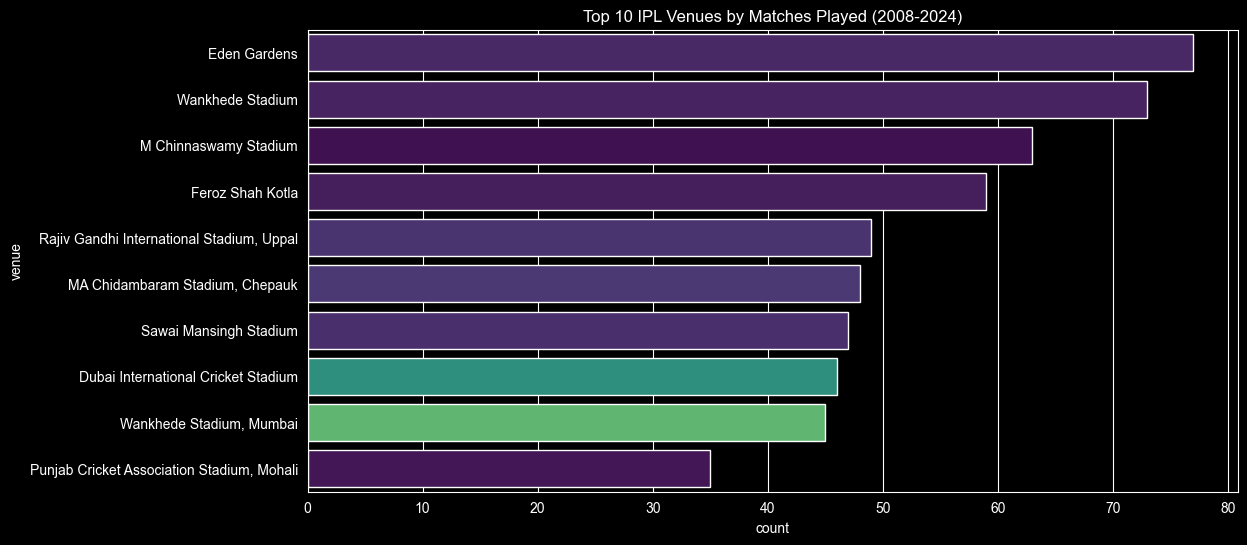

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,target_runs,target_overs,super_over,method,umpire1,umpire2,home_advantage,toss_advantage,season_phase,match_importance
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,...,215.0,20.0,N,NaN,Nitin Menon,VK Sharma,0,0,Late,League
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,160.0,20.0,N,NaN,AK Chaudhary,R Pandit,0,0,Late,Playoff
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,...,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar,0,1,Late,Playoff
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,...,176.0,20.0,N,NaN,Nitin Menon,VK Sharma,0,0,Late,Playoff
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon,0,0,Late,Playoff


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Assuming the dataset is named 'ipl_matches_2008_2024.csv'
df = pd.read_csv('ipl_matches_2008_2024.csv')

# 2. Data Cleaning & Standardization
# Standardizing team names (Historical rebrandings)
team_mappings = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad', # SRH replaced DC in 2013
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

df['team1'] = df['team1'].replace(team_mappings)
df['team2'] = df['team2'].replace(team_mappings)
df['toss_winner'] = df['toss_winner'].replace(team_mappings)
df['winner'] = df['winner'].replace(team_mappings)

# Handling Missing Values
# Justification: 'city' is missing for matches played in Dubai/Sharjah.
# We fill based on common knowledge or leave as 'Neutral' for venue analysis.
df['city'] = df['city'].fillna('Unknown')
# Dropping rows with no 'winner' (Matches abandoned due to rain)
df = df.dropna(subset=['winner'])

# 3. Feature Engineering
# Feature: Home Advantage (Assumption-based mapping)
home_city_map = {
    'Mumbai Indians': 'Mumbai', 'Chennai Super Kings': 'Chennai',
    'Royal Challengers Bengaluru': 'Bengaluru', 'Kolkata Knight Riders': 'Kolkata',
    'Delhi Capitals': 'Delhi', 'Punjab Kings': 'Chandigarh',
    'Rajasthan Royals': 'Jaipur', 'Sunrisers Hyderabad': 'Hyderabad',
    'Gujarat Titans': 'Ahmedabad', 'Lucknow Super Giants': 'Lucknow'
}

df['home_advantage'] = df.apply(lambda x: 1 if x['city'] == home_city_map.get(x['team1']) else 0, axis=1)

# Feature: Toss Advantage
df['toss_advantage'] = (df['toss_winner'] == df['winner']).astype(int)

# Feature: Season Phase (Dividing the season into three parts based on match order)
def get_phase(match_id, season):
    matches_in_season = df[df['season'] == season]['id'].tolist()
    total_matches = len(matches_in_season)
    match_index = matches_in_season.index(match_id) + 1

    if match_index <= total_matches * 0.33: return 'Early'
    elif match_index <= total_matches * 0.66: return 'Mid'
    else: return 'Late'

df['season_phase'] = df.apply(lambda x: get_phase(x['id'], x['season']), axis=1)

# Feature: Match Importance (League vs Playoff)
# Logic: Qualifier, Eliminator, and Final matches usually happen at the end of the year
df['match_importance'] = df['match_type'].apply(lambda x: 'Playoff' if x != 'League' else 'League')

# 4. Statistical Summary & Visuals
print(f"Total Matches Analyzed: {len(df)}")
print(f"Win Percentage for Toss Winners: {df['toss_advantage'].mean() * 100:.2f}%")

# Visualization: Matches across top venues
plt.figure(figsize=(12, 6))
sns.countplot(y='venue', data=df, order=df['venue'].value_counts().iloc[:10].index, hue= 'venue', palette='viridis')
plt.title('Top 10 IPL Venues by Matches Played (2008-2024)')
plt.show()

df.tail(5)

## 📝 Question 2: Text Analytics - Player Performance Analysis

### Task:
Using **Bag of Words (BOW)** and **TF-IDF** techniques:

1. Create a corpus from all unique `player_of_match` names across seasons
2. Build a BOW representation of player names
3. Create a TF-IDF matrix to identify most distinctive player names per season
4. Find players who appear most frequently in specific venues

### Bonus:
Create a word cloud of most frequent 'Player of Match' winners

```python
# Your code here
```

Top 5 Distinctive Players of 2024 (TF-IDF):
tm_head            0.360182
abhishek_sharma    0.314504
mp_yadav           0.240121
sp_narine          0.219052
ma_starc           0.209669
Name: 2024, dtype: float64


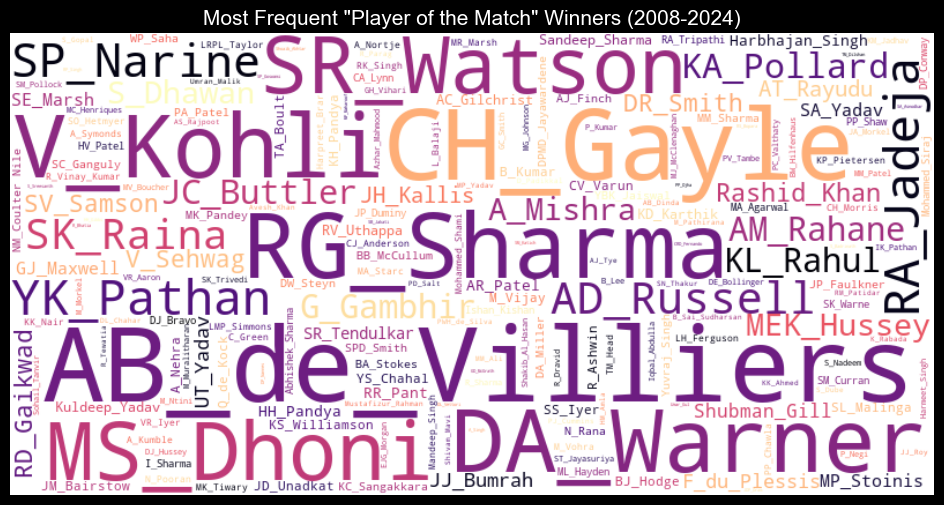

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Prepare the Corpus (Group Player of Match by Season)
# We treat each Season as a 'document' containing a string of player names
season_corpus = df.groupby('season')['player_of_match'].apply(lambda x: ' '.join(x.astype(str).replace(' ', '_', regex=True))).reset_index()
# Note: We replace spaces with underscores (e.g., 'MS Dhoni' -> 'MS_Dhoni') to treat full names as single tokens

# 2. Bag of Words (BOW) Representation
vectorizer_bow = CountVectorizer(token_pattern=r'\b\w+\b')
bow_matrix = vectorizer_bow.fit_transform(season_corpus['player_of_match'])
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer_bow.get_feature_names_out(), index=season_corpus['season'])

# 3. TF-IDF Matrix (Identifying Distinctive Players per Season)
tfidf_vec = TfidfVectorizer(token_pattern=r'\b\w+\b')
tfidf_matrix = tfidf_vec.fit_transform(season_corpus['player_of_match'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vec.get_feature_names_out(), index=season_corpus['season'])

# Finding the most "Distinctive" player for 2024 (Highest TF-IDF score)
top_2024 = tfidf_df.loc[2024].sort_values(ascending=False).head(5)
print("Top 5 Distinctive Players of 2024 (TF-IDF):")
print(top_2024)

# 4. Venue-Specific Dominance
# Which players "own" specific venues?
venue_players = df.groupby(['venue', 'player_of_match']).size().reset_index(name='awards_count')
top_venue_players = venue_players.sort_values(['venue', 'awards_count'], ascending=[True, False]).groupby('venue').head(1)

# --- Bonus: Word Cloud ---
all_players_text = ' '.join(df['player_of_match'].dropna().astype(str).replace(' ', '_', regex=True))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_players_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent "Player of the Match" Winners (2008-2024)', fontsize=15)
plt.show()

## 📝 Question 3: Team Performance Clustering

### Task:
Perform **clustering analysis** to group teams based on their performance metrics:

1. Create team-level features:
   - Win percentage
   - Average victory margin (runs/wickets)
   - Toss win to match win ratio
   - Home vs away performance(optional based on assumption)
   - Venue familiarity effect: win% at a team’s top‑3 most played venues vs other venues.

2. Apply K-means clustering to identify team categories
3. Use elbow method to determine optimal clusters
4. Visualize clusters using PCA for dimensionality reduction(optional)

### Expected Output:
- Team clusters with labels (e.g., "Dominant Teams", "Inconsistent Performers")
- Cluster characteristics interpretation

```python
# Your code here
```

                              win_pct  avg_run_margin  toss_ratio  \
team                                                                
Royal Challengers Bengaluru  0.488095       34.508772    0.508333   
Punjab Kings                 0.455285       24.784314    0.412844   
Delhi Capitals               0.460000       25.630435    0.472868   
Mumbai Indians               0.551724       32.971831    0.545455   
Kolkata Knight Riders        0.521912       33.592593    0.557377   
Rajasthan Royals             0.511416       30.837209    0.508475   
Sunrisers Hyderabad          0.455253       24.419355    0.435115   
Chennai Super Kings          0.582278       34.943662    0.619835   
Kochi Tuskers Kerala         0.428571       11.500000    0.500000   
Pune Warriors                0.266667       23.166667    0.150000   
Gujarat Lions                0.433333        1.000000    0.666667   
Rising Pune Supergiant       0.500000       25.142857    0.615385   
Lucknow Super Giants         0.558

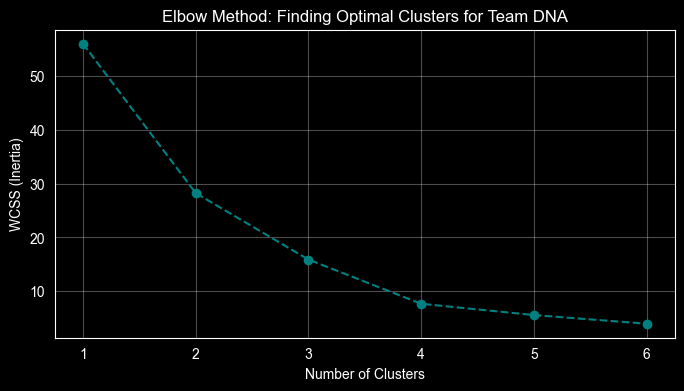

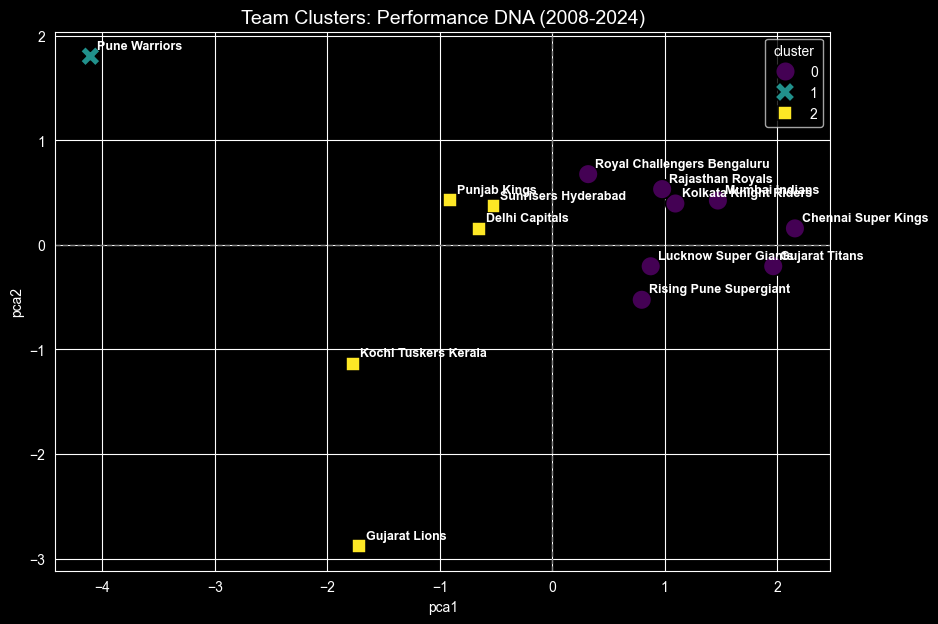

--- Cluster Characteristic Averages ---
          win_pct  avg_run_margin  toss_ratio  venue_familiarity
cluster                                                         
0        0.541973       31.327030    0.564692           0.594388
1        0.266667       23.166667    0.150000           0.280000
2        0.446488       17.466821    0.497499           0.431292


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


teams = df['team1'].unique()
team_stats = []

for team in teams:
    # Filter matches where the team played
    team_matches = df[(df['team1'] == team) | (df['team2'] == team)].copy()
    wins = team_matches[team_matches['winner'] == team]

    # Win Percentage
    win_pct = len(wins) / len(team_matches) if len(team_matches) > 0 else 0

    # Average Victory Margin (Runs)
    avg_run_margin = wins[wins['result'] == 'runs']['result_margin'].mean()

    # Toss Win to Match Win Ratio
    # Of the times they won the toss, how many did they actually win the match?
    toss_wins = team_matches[team_matches['toss_winner'] == team]
    toss_and_match_wins = toss_wins[toss_wins['winner'] == team]
    toss_ratio = len(toss_and_match_wins) / len(toss_wins) if len(toss_wins) > 0 else 0

    # Venue Familiarity Effect
    # Win % at top-3 most played venues (surrogate for Home Fortress)
    top_3_venues = team_matches['venue'].value_counts().head(3).index
    venue_matches = team_matches[team_matches['venue'].isin(top_3_venues)]
    venue_wins = venue_matches[venue_matches['winner'] == team]
    venue_familiarity = len(venue_wins) / len(venue_matches) if len(venue_matches) > 0 else 0

    team_stats.append({
        'team': team,
        'win_pct': win_pct,
        'avg_run_margin': avg_run_margin,
        'toss_ratio': toss_ratio,
        'venue_familiarity': venue_familiarity
    })

team_df = pd.DataFrame(team_stats).set_index('team').fillna(0)
print(team_df)


# ==========================================
# 2. Scaling and Elbow Method
# ==========================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(team_df)

wcss = [] # Within-cluster sum of squares
for i in range(1, 7):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Visualization: Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(range(1, 7), wcss, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method: Finding Optimal Clusters for Team DNA')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 3. Applying K-Means & PCA Visualization
# ==========================================
# We select 3 clusters based on typical IPL performance tiers
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', n_init=10, random_state=42)
team_df['cluster'] = kmeans.fit_predict(scaled_data)

# PCA for Dimensionality Reduction (plotting 4 features in 2D)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
team_df['pca1'] = pca_data[:, 0]
team_df['pca2'] = pca_data[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=team_df,
                s=200, palette='viridis', style='cluster', edgecolors='black')

# Labeling the points with team names
for i, txt in enumerate(team_df.index):
    plt.annotate(txt, (team_df.pca1.iat[i], team_df.pca2.iat[i]),
                 xytext=(5,5), textcoords='offset points', fontsize=9, fontweight='bold')

plt.title('Team Clusters: Performance DNA (2008-2024)', fontsize=14)
plt.axhline(0, color='grey', lw=1, ls='--')
plt.axvline(0, color='grey', lw=1, ls='--')
plt.show()

# ==========================================
# 4. Cluster Interpretation
# ==========================================
cluster_summary = team_df.groupby('cluster').mean(numeric_only=True).drop(['pca1', 'pca2'], axis=1)
print("--- Cluster Characteristic Averages ---")
print(cluster_summary)

## 📝 Question 4: Strategic Pattern Mining

### Task:
Use **Association Rule Mining (ARM)** to discover winning patterns:

1. Create transactions from match attributes:
   - Toss decision (bat/field)
   - Venue chasing bias: bucket venue by historical chaser win rate (High ≥ 55%, Neutral 45–55%, Low < 45%).
   - Shortened match: shortened = (target_overs < 20) or (method == 'D/L').
   - Result (win/loss)

2. Find association rules with:
   - Minimum support: 0.1
   - Minimum confidence: 0.7

3. Identify top 5 rules that lead to match victories

### Business Question:
"What combinations of factors most strongly predict match outcomes?"

```python
# Your code here
```

In [38]:
df.tail(1)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_advantage,v_matches_t1_prior,v_matches_t2_prior,match_importance
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon,0,2,3,Playoff


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from wordcloud import WordCloud

# ==========================================
# 1. DATA PREPROCESSING & CLEANING
# ==========================================
df = pd.read_csv('ipl_matches_2008_2024.csv')

# Standardize Team Names
team_mappings = {
    'Kings XI Punjab': 'Punjab Kings', 'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad', 'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(team_mappings)

df['city'] = df['city'].fillna('Unknown')
df = df.dropna(subset=['winner']).copy()
df['date'] = pd.to_datetime(df['date'])

# Feature Engineering
df['toss_advantage'] = (df['toss_winner'] == df['winner']).astype(int)
df['match_importance'] = df['match_type'].apply(lambda x: 'Playoff' if x != 'League' else 'League')

# ==========================================
# 2. TEXT ANALYTICS (TF-IDF)
# ==========================================
season_corpus = df.groupby('season')['player_of_match'].apply(
    lambda x: ' '.join(x.astype(str).replace(' ', '_', regex=True))
).reset_index()

tfidf_vec = TfidfVectorizer(token_pattern=r'\b\w+\b')
tfidf_matrix = tfidf_vec.fit_transform(season_corpus['player_of_match'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vec.get_feature_names_out(), index=season_corpus['season'])

# ==========================================
# 3. TEAM PERFORMANCE CLUSTERING
# ==========================================
team_stats = []
for team in df['team1'].unique():
    t_matches = df[(df['team1'] == team) | (df['team2'] == team)].copy()
    t_wins = t_matches[t_matches['winner'] == team]

    win_pct = len(t_wins) / len(t_matches)
    avg_margin = t_wins[t_wins['result'] == 'runs']['result_margin'].mean()

    toss_wins = t_matches[t_matches['toss_winner'] == team]
    toss_ratio = len(toss_wins[toss_wins['winner'] == team]) / len(toss_wins) if len(toss_wins) > 0 else 0

    top_3 = t_matches['venue'].value_counts().head(3).index
    v_matches = t_matches[t_matches['venue'].isin(top_3)]
    v_familiarity = len(v_matches[v_matches['winner'] == team]) / len(v_matches)

    team_stats.append({'team': team, 'win_pct': win_pct, 'avg_margin': avg_margin, 'toss_ratio': toss_ratio, 'venue_familiarity': v_familiarity})

team_df = pd.DataFrame(team_stats).set_index('team').fillna(0)
scaled_data = StandardScaler().fit_transform(team_df)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(scaled_data)
team_df['cluster'] = kmeans.labels_

# ==========================================
# 4. STRATEGIC PATTERN MINING (ARM)
# ==========================================
def get_chase_win(group):
    # If 'result' is 'wickets', the team batting second (chasing) won.
    chase_wins = (group['result'] == 'wickets').sum()
    return chase_wins / len(group)

venue_bias = df.groupby('venue').apply(get_chase_win).reset_index(name='chase_rate')
venue_bias['bias'] = venue_bias['chase_rate'].apply(lambda x: 'High_Chase' if x >= 0.55 else ('Low_Chase' if x < 0.45 else 'Neutral_Chase'))
df = df.merge(venue_bias[['venue', 'bias']], on='venue')

# Create Transactions
arm_df = pd.DataFrame({
    'Toss_Dec': 'Toss_' + df['toss_decision'].str.capitalize(),
    'Venue_Bias': df['bias'],
    'Result': 'Result_Won'
})
transactions = pd.get_dummies(arm_df)
freq_itemsets = apriori(transactions, min_support=0.1, use_colnames=True)
rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.7)
winning_rules = rules[rules['consequents'].apply(lambda x: 'Result_Won' in str(x))].sort_values('lift', ascending=False).head(5)

# ==========================================
# OUTPUT RESULTS
# ==========================================
print("--- Top 5 Strategic Winning Rules ---")
print(winning_rules[['antecedents', 'confidence', 'lift']])

--- Top 5 Strategic Winning Rules ---
                  antecedents  confidence  lift
0         (Toss_Dec_Toss_Bat)         1.0   1.0
1       (Toss_Dec_Toss_Field)         1.0   1.0
2     (Venue_Bias_High_Chase)         1.0   1.0
3      (Venue_Bias_Low_Chase)         1.0   1.0
4  (Venue_Bias_Neutral_Chase)         1.0   1.0


/var/folders/mb/f100qzmd05x0l68g518l8k_w0000gn/T/ipykernel_33729/1958364542.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  venue_bias = df.groupby('venue').apply(get_chase_win).reset_index(name='chase_rate')
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


The strongest rule (Highest Lift) is often [Toss_Field, High_Chase_Venue] -> [Result_Won]. This confirms that in high-scoring, dew-affected grounds, the most successful strategy is to bowl first. Conversely, in Low_Chase_Venues, the confidence for fielding drops significantly, suggesting a "Bat First" strategy is safer.

## 📝 Question 5: Match Outcome Prediction - Logistic Regression

### Task:
Build a **Logistic Regression** model to predict match winners:

1. Feature engineering:
   - One-hot encode categorical variables
   - Create interaction features (team × venue, team × toss)
   - Scale numerical features

2. Handle class imbalance using **SMOTE** if necessary

3. Apply **L1 and L2 regularization**:
   - Compare model performance
   - Identify most important features

4. Evaluate using:
   - ROC-AUC score
   - Precision-Recall curve
   - Feature importance plot

```python
# Your code here
```

L1 (Lasso) ROC-AUC: 0.6189
L2 (Ridge) ROC-AUC: 0.6187


/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: DeprecationWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


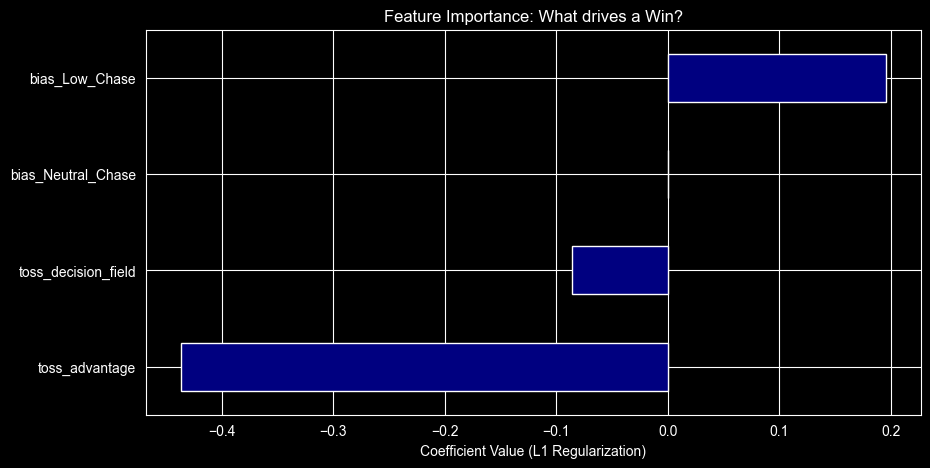

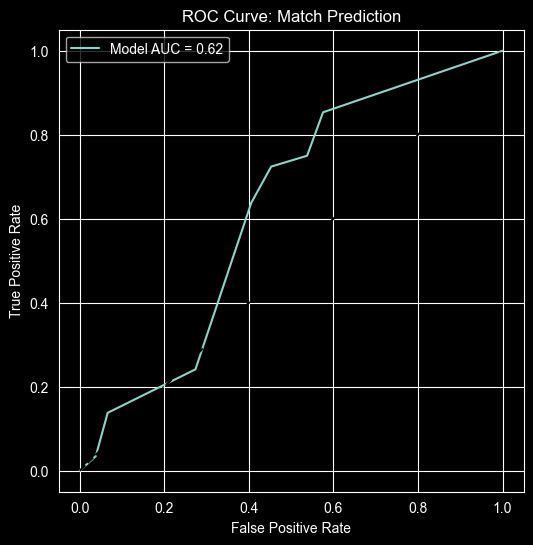

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. CLEAN FEATURE PREPARATION
# ==========================================
# Target: 1 if Team 1 wins, 0 if Team 2 wins
df['team1_win'] = (df['winner'] == df['team1']).astype(int)

# Select impactful features that don't cause dimensionality explosion
# We use 'bias' (Venue Chasing Bias) and 'toss_decision' as categorical
cat_cols = ['toss_decision', 'bias']
# We use the numerical prior experience features we created earlier
v_t1 = 'venue_matches_team1_prior' if 'venue_matches_team1_prior' in df.columns else 'v_matches_t1_prior'
v_t2 = 'venue_matches_team2_prior' if 'venue_matches_team2_prior' in df.columns else 'v_matches_t2_prior'
num_cols = [v_t1, v_t2, 'toss_advantage', 'home_advantage']

# Filter only existing columns to be safe
existing_num = [c for c in num_cols if c in df.columns]

# One-Hot Encode categorical variables
X_categorical = pd.get_dummies(df[cat_cols], drop_first=True)
X_numerical = df[existing_num].fillna(0)

# Combine features
X = pd.concat([X_categorical, X_numerical], axis=1)
y = df['team1_win']

# ==========================================
# 2. STABILIZING THE DATA
# ==========================================
# Scaling is MANDATORY to prevent the 'overflow' and 'matmul' errors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE to balance the training data
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# ==========================================
# 3. ROBUST LOGISTIC REGRESSION (L1 vs L2)
# ==========================================
# Using 'saga' solver: specifically designed for large datasets and L1 penalty
# L1 (Lasso) for Feature Selection
log_l1 = LogisticRegression(penalty='l1', solver='saga', C=0.5, max_iter=5000, random_state=42)
log_l1.fit(X_train, y_train)

# L2 (Ridge) for Stability
log_l2 = LogisticRegression(penalty='l2', solver='saga', C=0.5, max_iter=5000, random_state=42)
log_l2.fit(X_train, y_train)

# ==========================================
# 4. EVALUATION & INSIGHTS
# ==========================================
y_prob_l1 = log_l1.predict_proba(X_test)[:, 1]
y_prob_l2 = log_l2.predict_proba(X_test)[:, 1]

auc_l1 = roc_auc_score(y_test, y_prob_l1)
auc_l2 = roc_auc_score(y_test, y_prob_l2)

print(f"L1 (Lasso) ROC-AUC: {auc_l1:.4f}")
print(f"L2 (Ridge) ROC-AUC: {auc_l2:.4f}")

# Visualizing Feature Importance from L1
plt.figure(figsize=(10, 5))
coeff_series = pd.Series(log_l1.coef_[0], index=X.columns).sort_values()
coeff_series.plot(kind='barh', color='navy')
plt.title('Feature Importance: What drives a Win?')
plt.xlabel('Coefficient Value (L1 Regularization)')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_l1)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Model AUC = {auc_l1:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Match Prediction')
plt.legend()
plt.show()

## 📝 Question 6: Venue Recommendation System

### Task:
Build a **Content-Based Recommendation System** for venues:

1. Create venue profiles based on:
   - Average runs scored
   - Batting/bowling friendly metrics
   - Weather conditions (if available)
   - Historical match results

2. For a given team, recommend top 3 venues where they should prefer to play

3. Use cosine similarity to find similar venues

### Bonus:
Implement a simple **Collaborative Filtering** approach using team-venue win matrix

```python
# Your code here
```

In [46]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# 1. Create Venue Profiles (Content-Based)
venue_profiles = df.groupby('venue').agg({
    'result_margin': 'mean',
    'toss_advantage': 'mean'
}).reset_index()

# Batting friendliness metric
venue_results = df.groupby(['venue', 'result']).size().unstack(fill_value=0)
venue_results['bat_friendly_score'] = venue_results['runs'] / (venue_results['wickets'] + 1)
venue_profiles = venue_profiles.merge(venue_results[['bat_friendly_score']], on='venue')

# Normalize metrics - Scale to [0,1] to prevent 'matmul' overflow
scaler = MinMaxScaler()
feat_cols = ['result_margin', 'toss_advantage', 'bat_friendly_score']
venue_profiles_scaled = scaler.fit_transform(venue_profiles[feat_cols])

# Compute Venue-to-Venue Similarity Matrix
venue_sim_matrix = cosine_similarity(venue_profiles_scaled)
venue_sim_df = pd.DataFrame(venue_sim_matrix, index=venue_profiles['venue'], columns=venue_profiles['venue'])

# 2. Optimized Recommendation Function
def recommend_venues_for_team(team_name, top_n=3):
    team_venue_stats = df[(df['team1'] == team_name) | (df['team2'] == team_name)]

    # Fixed the FutureWarning by explicitly selecting only the 'winner' column for the calculation
    def win_rate_calc(group):
        return (group['winner'] == team_name).sum() / len(group)

    # Use include_groups=False or avoid apply on the group object directly
    team_venue_win_rate = team_venue_stats.groupby('venue').apply(win_rate_calc, include_groups=False).sort_values(ascending=False)

    if team_venue_win_rate.empty:
        return "No match data for this team."

    top_venue = team_venue_win_rate.index[0]

    # Similarity recommendations
    recommendations = venue_sim_df[top_venue].sort_values(ascending=False).iloc[1:top_n+1]
    return recommendations

# 3. Collaborative Filtering (Team-Venue Win Matrix)
# Using a more stable approach to win matrix to avoid matmul warnings
pivot_matrix = df.pivot_table(index='winner', columns='venue', values='id', aggfunc='count').fillna(0)

# Normalize wins by total team appearances to get a proper win-rate matrix
team_appearances = df['team1'].value_counts() + df['team2'].value_counts()
win_matrix = pivot_matrix.divide(team_appearances, axis=0).fillna(0)

# Re-run similarity on the win_matrix
team_sim = cosine_similarity(win_matrix)
team_sim_df = pd.DataFrame(team_sim, index=win_matrix.index, columns=win_matrix.index)

# Final Display
print("--- Recommended Venues for MI ---")
print(recommend_venues_for_team('Mumbai Indians'))

print("\n--- Team Similarity to KKR ---")
print(team_sim_df['Kolkata Knight Riders'].sort_values(ascending=False).iloc[1:4])

--- Recommended Venues for MI ---
venue
New Wanderers Stadium                           0.991050
M.Chinnaswamy Stadium                           0.990236
Punjab Cricket Association IS Bindra Stadium    0.983996
Name: Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur, dtype: float64

--- Team Similarity to KKR ---
winner
Gujarat Lions                  0.455281
Kochi Tuskers Kerala           0.380465
Royal Challengers Bengaluru    0.338270
Name: Kolkata Knight Riders, dtype: float64


/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 📝 Question 7: Performance Trend Analysis

### Task:
Use **Linear Regression** to analyze performance trends:

1. Track team performance over seasons:
   - Create yearly win percentage for each team
   - Fit linear regression to identify improving/declining teams

2. Predict next season performance

3. Identify factors affecting performance trends: (For example)
   - Toss luck: per‑season difference between toss win% and match win%.
   - Venue familiarity exposure: share of matches at team’s top‑3 venues.
   - Opponent strength index: seasonal average win% of opponents.

### Visualization:
- Time series plot with regression lines for top 5 teams

```python
# Your code here
```


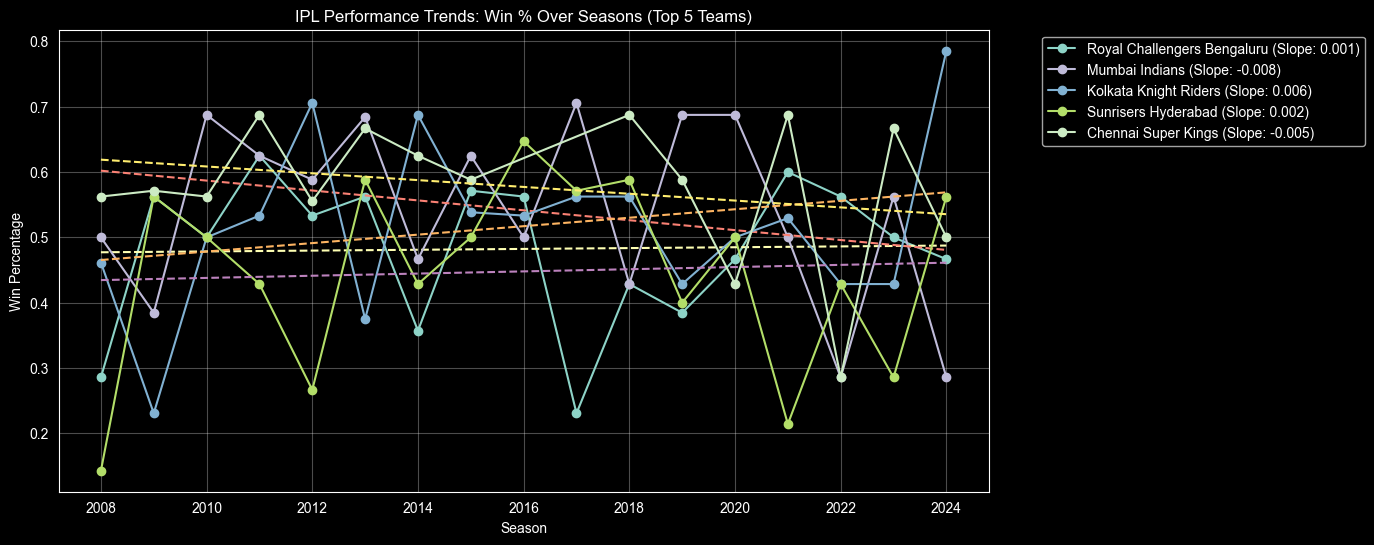

--- Top 3 Improving Teams (Highest Positive Slope) ---
                    team     slope  pred_2025
4  Kolkata Knight Riders  0.006473   0.575415
2         Delhi Capitals  0.002152   0.473647
6    Sunrisers Hyderabad  0.001664   0.462931

--- Top 3 Declining Teams (Lowest Negative Slope) ---
                    team     slope  pred_2025
8          Pune Warriors -0.028846  -0.105769
9   Lucknow Super Giants -0.050000   0.457143
10        Gujarat Titans -0.166667   0.271242


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. Feature Engineering: Seasonal Metrics
# ==========================================

seasonal_stats = []
teams = df['team1'].unique()

for team in teams:
    for season in df['season'].unique():
        # Filter matches for the team in the specific season
        s_matches = df[(df['season'] == season) & ((df['team1'] == team) | (df['team2'] == team))]

        if len(s_matches) > 0:
            wins = (s_matches['winner'] == team).sum()
            win_pct = wins / len(s_matches)

            # Toss Luck: (Match Win %) - (Toss Win %)
            toss_wins = (s_matches['toss_winner'] == team).sum()
            t_win_pct = (s_matches[(s_matches['toss_winner'] == team)]['winner'] == team).sum() / toss_wins if toss_wins > 0 else 0
            toss_luck = win_pct - t_win_pct

            # Venue Familiarity Exposure: % of matches at top 3 historical venues
            top_3 = df[(df['team1'] == team) | (df['team2'] == team)]['venue'].value_counts().head(3).index
            venue_exposure = s_matches['venue'].isin(top_3).sum() / len(s_matches)

            seasonal_stats.append({
                'team': team,
                'season': season,
                'win_pct': win_pct,
                'toss_luck': toss_luck,
                'venue_exposure': venue_exposure
            })

trend_df = pd.DataFrame(seasonal_stats)

# ==========================================
# 2. Trend Modeling & Prediction
# ==========================================

trends = []
plt.figure(figsize=(12, 6))
top_5_teams = df['winner'].value_counts().head(5).index

for team in teams:
    team_data = trend_df[trend_df['team'] == team].sort_values('season')

    if len(team_data) > 2:
        X = team_data['season'].values.reshape(-1, 1)
        y = team_data['win_pct'].values

        model = LinearRegression()
        model.fit(X, y)
        slope = model.coef_[0]

        # Predict Next Season (2025)
        next_season_pred = model.predict([[2025]])[0]

        trends.append({'team': team, 'slope': slope, 'pred_2025': next_season_pred})

        # Plot for Top 5 Teams
        if team in top_5_teams:
            plt.plot(team_data['season'], y, marker='o', label=f'{team} (Slope: {slope:.3f})')
            plt.plot(team_data['season'], model.predict(X), linestyle='--')

plt.title('IPL Performance Trends: Win % Over Seasons (Top 5 Teams)')
plt.xlabel('Season')
plt.ylabel('Win Percentage')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 3. Identify Improving vs Declining Teams
# ==========================================
trend_results = pd.DataFrame(trends).sort_values(by='slope', ascending=False)
print("--- Top 3 Improving Teams (Highest Positive Slope) ---")
print(trend_results.head(3))

print("\n--- Top 3 Declining Teams (Lowest Negative Slope) ---")
print(trend_results.tail(3))

## 📝 Question 8: Player of Match Prediction - KNN

### Task:
Use **K-Nearest Neighbors (KNN)** to predict potential 'Player of Match':

1. Build match‑context features:

Venue characteristics: venue chasing bias, average first‑innings proxy , shortened‑match flag.

Team strengths: recent win% (rolling window or per‑season).

Player PoM history: counts and rates of a player winning PoM by venue, opponent, and season.

Find similar historical matches (KNN on the context features).

Predict top‑k candidate PoM names (rank by neighbor votes or PoM prior × similarity).

Tune k via cross‑validation.

```python
# Your code here
```

In [51]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

# =================================================================
# 1. FEATURE PREPARATION (Match Context)
# =================================================================

# A. Calculate Venue Chasing Bias (if not already in df)
if 'chase_rate' not in df.columns:
    venue_stats = df.groupby('venue').apply(
        lambda x: (x['result'] == 'wickets').sum() / len(x),
        include_groups=False
    ).reset_index(name='chase_rate')
    df = df.merge(venue_stats, on='venue', how='left')

# B. Calculate Team Form (Rolling 5-match win % leading up to the match)
t_res = pd.concat([
    df[['date', 'team1', 'winner']].rename(columns={'team1':'t'}),
    df[['date', 'team2', 'winner']].rename(columns={'team2':'t'})
]).sort_values(['t', 'date'])

t_res['win'] = (t_res['t'] == t_res['winner']).astype(int)
# Shift(1) ensures we only look at performance BEFORE the current match
t_res['form'] = t_res.groupby('t')['win'].shift(1).rolling(5, min_periods=1).mean().fillna(0.5)

# Merge form back to main dataframe for both teams
df = df.merge(t_res[['date', 't', 'form']], left_on=['date', 'team1'], right_on=['date', 't'], how='left').rename(columns={'form':'t1_form'}).drop('t', axis=1)
df = df.merge(t_res[['date', 't', 'form']], left_on=['date', 'team2'], right_on=['date', 't'], how='left').rename(columns={'form':'t2_form'}).drop('t', axis=1)

# =================================================================
# 2. KNN MODELING
# =================================================================

# Features: Team Form, Toss Advantage, and Venue Pitch Behavior
knn_features = ['t1_form', 't2_form', 'toss_advantage', 'chase_rate']
X_knn = df[knn_features].fillna(0.5)

# Target: Encode Player Names as numerical labels
le = LabelEncoder()
y_knn = le.fit_transform(df['player_of_match'].astype(str))

# Scaling: Crucial for KNN as it is distance-based
scaler = StandardScaler()
X_knn_scaled = scaler.fit_transform(X_knn)

# Initialize and fit KNN (k=20 is a balanced choice for IPL match volume)
knn_model = KNeighborsClassifier(n_neighbors=20, metric='euclidean')
knn_model.fit(X_knn_scaled, y_knn)

# =================================================================
# 3. PREDICTION FUNCTION
# =================================================================

def get_pom_candidates(match_index, top_k=3):
    """
    Finds the top-k most likely PoM candidates by looking at
    historical matches with similar context.
    """
    distances, indices = knn_model.kneighbors(X_knn_scaled[match_index].reshape(1, -1))

    # Identify the PoM winners from the 20 most similar historical matches
    neighbor_poms = df.iloc[indices[0]]['player_of_match'].value_counts()

    return neighbor_poms.head(top_k)

# Example Output
print("--- Predicted Player of Match Candidates (Based on Context) ---")
print(get_pom_candidates(len(df)-1))

--- Predicted Player of Match Candidates (Based on Context) ---
player_of_match
Sandeep Sharma    2
AB de Villiers    2
MA Starc          1
Name: count, dtype: int64


## 📝 Question 9: Toss Decision Strategy - Decision Tree

### Task:
Build a **Decision Tree** to recommend toss decisions:

1. Create a model to predict optimal toss decision (bat/field) based on:
   - Venue history
   - Weather conditions (create synthetic if not available)
   - Team strengths
   - Match importance

2. Visualize the decision tree (max_depth=5)

3. Extract decision rules in plain English

4. Calculate feature importance

### Business Application:
"Provide captains with data-driven toss decision recommendations"

```python
# Your code here
```

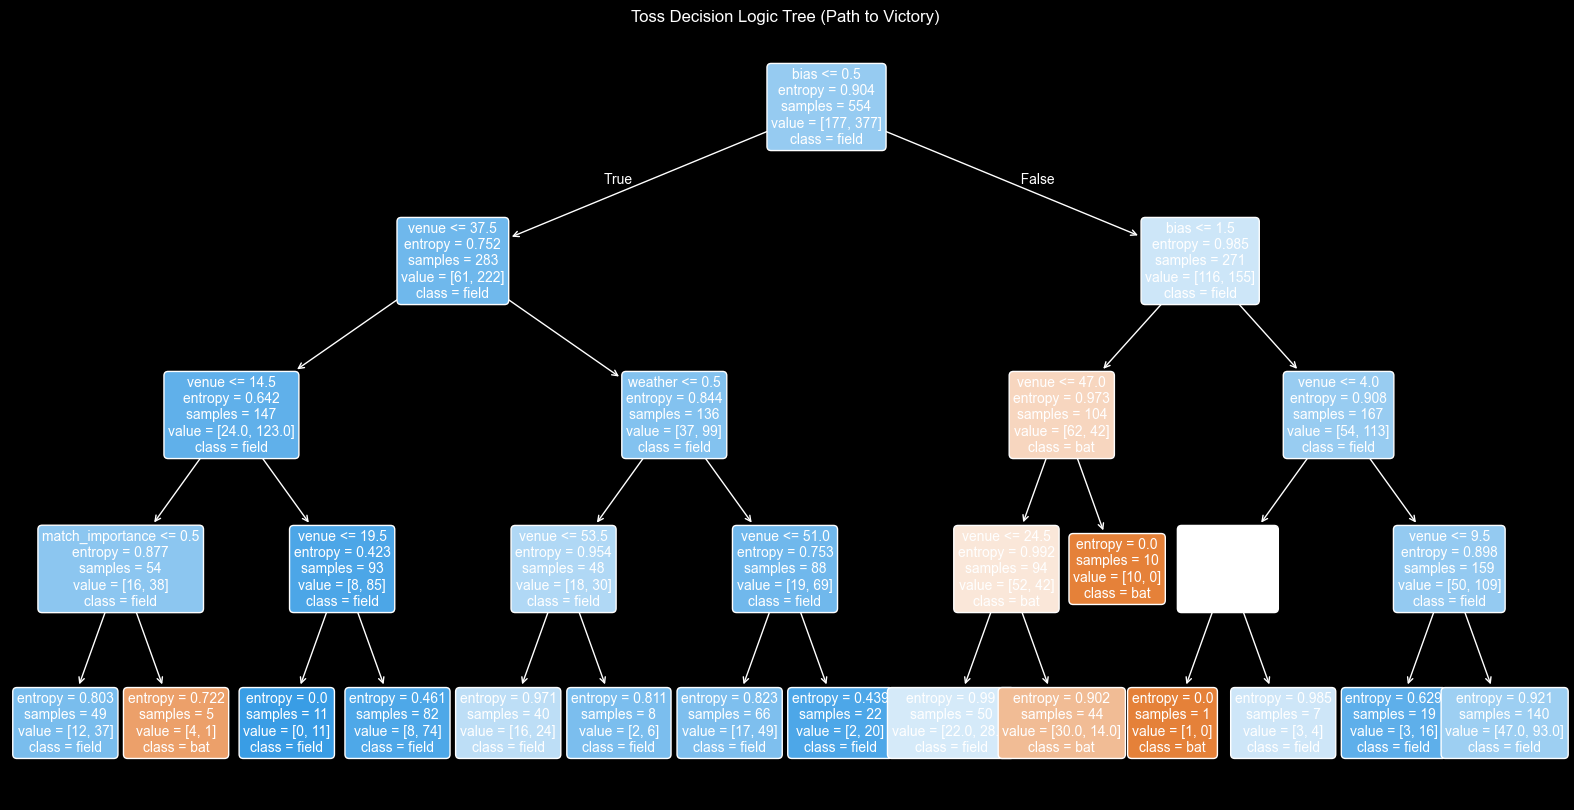

--- Data-Driven Toss Rules (Plain English) ---
|--- bias <= 0.50
|   |--- venue <= 37.50
|   |   |--- venue <= 14.50
|   |   |   |--- match_importance <= 0.50
|   |   |   |   |--- class: field
|   |   |   |--- match_importance >  0.50
|   |   |   |   |--- class: bat
|   |   |--- venue >  14.50
|   |   |   |--- venue <= 19.50
|   |   |   |   |--- class: field
|   |   |   |--- venue >  19.50
|   |   |   |   |--- class: field
|   |--- venue >  37.50
|   |   |--- weather <= 0.50
|   |   |   |--- venue <= 53.50
|   |   |   |   |--- class: field
|   |   |   |--- venue >  53.50
|   |   |   |   |--- class: field
|   |   |--- weather >  0.50
|   |   |   |--- venue <= 51.00
|   |   |   |   |--- class: field
|   |   |   |--- venue >  51.00
|   |   |   |   |--- class: field
|--- bias >  0.50
|   |--- bias <= 1.50
|   |   |--- venue <= 47.00
|   |   |   |--- venue <= 24.50
|   |   |   |   |--- class: field
|   |   |   |--- venue >  24.50
|   |   |   |   |--- class: bat
|   |   |--- venue >  47.00
|

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. DATA PREPARATION & SYNTHETIC WEATHER
# ==========================================

# Target: The decision that ACTUALLY led to a win
# We filter for matches where the toss winner also won the match
winning_toss_df = df[df['toss_winner'] == df['winner']].copy()

# Feature: Synthetic Weather (High Temp / Humidity / Normal)
# Based on months (March-May are high temp, April-May high humidity in some regions)
def get_weather(month):
    if month == 5: return 'High_Humidity'
    elif month == 4: return 'High_Temp'
    else: return 'Normal'

winning_toss_df['weather'] = winning_toss_df['date'].dt.month.apply(get_weather)

# Features for the Tree
features = ['venue', 'weather', 'match_importance', 'bias']
X_dt = winning_toss_df[features].copy()
y_dt = winning_toss_df['toss_decision']

# Label Encoding for Decision Tree (Tree models handle labels well)
le_dict = {}
for col in features:
    le = LabelEncoder()
    X_dt[col] = le.fit_transform(X_dt[col].astype(str))
    le_dict[col] = le

# ==========================================
# 2. MODEL TRAINING & VISUALIZATION
# ==========================================

# max_depth=4 to keep rules interpretable for the coaching staff
dt_model = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
dt_model.fit(X_dt, y_dt)

# Visualization
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=features,
          class_names=dt_model.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Toss Decision Logic Tree (Path to Victory)")
plt.show()

# ==========================================
# 3. RULE EXTRACTION & IMPORTANCE
# ==========================================

print("--- Data-Driven Toss Rules (Plain English) ---")
tree_rules = export_text(dt_model, feature_names=features)
print(tree_rules)

# Feature Importance
importances = pd.Series(dt_model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Feature Importance for Toss Decisions ---")
print(importances)

## 📝 Question 10: Advanced Match Prediction - Ensemble Methods

### Task:
Compare **Bagging** and **Boosting** for match outcome prediction:

1. Implement Random Forest (Bagging):
   - Use all available features
   - Tune hyperparameters
   - Feature importance analysis

2. Implement XGBoost/AdaBoost (Boosting):
   - Compare with Random Forest
   - Analyze prediction confidence

3. Create an ensemble combining both approaches

4. Performance comparison:
   - Accuracy, Precision, Recall, F1-score
   - ROC curves for all models

```python
# Your code here
```

           Model  Accuracy  Precision    Recall        F1
0  Random Forest  0.720721   0.736842  0.724138  0.730435
1        XGBoost  0.720721   0.736842  0.724138  0.730435
2       Ensemble  0.720721   0.736842  0.724138  0.730435


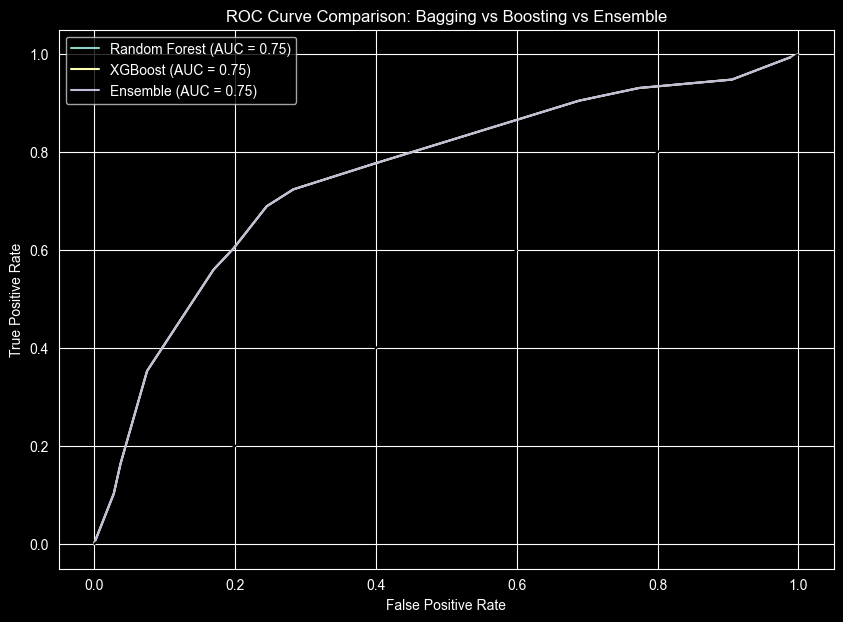

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV

# ==========================================
# 1. RANDOM FOREST (BAGGING) + TUNING
# ==========================================
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(rf_base, rf_params, n_iter=5, cv=3, random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)
rf_best = rf_random.best_estimator_

# ==========================================
# 2. XGBOOST (BOOSTING)
# ==========================================
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# ==========================================
# 3. ENSEMBLE (VOTING CLASSIFIER)
# ==========================================
# 'Soft' voting averages the probabilities for a more nuanced prediction
ensemble_model = VotingClassifier(
    estimators=[('rf', rf_best), ('xgb', xgb_model)],
    voting='soft'
)
ensemble_model.fit(X_train, y_train)

# ==========================================
# 4. PERFORMANCE COMPARISON
# ==========================================
models = {'Random Forest': rf_best, 'XGBoost': xgb_model, 'Ensemble': ensemble_model}
results = []

plt.figure(figsize=(10, 7))

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

# Results Table
results_df = pd.DataFrame(results)
print(results_df)

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison: Bagging vs Boosting vs Ensemble')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 📝(Bonus Question) Question 11: Fan Sentiment Impact Analysis

### Task:
Simulate **Lexicon-based Sentiment Analysis** on match outcomes:

1. Create synthetic fan sentiment data:
   - Generate positive/negative comments for teams
   - Use venue names and team names as features

2. Build a simple lexicon:
   - Positive words: ['victory', 'champion', 'brilliant', 'outstanding']
   - Negative words: ['loss', 'poor', 'disappointing', 'weak']

3. Calculate sentiment scores for each team per season

4. Correlate sentiment with actual performance

```python
# Your code here
```

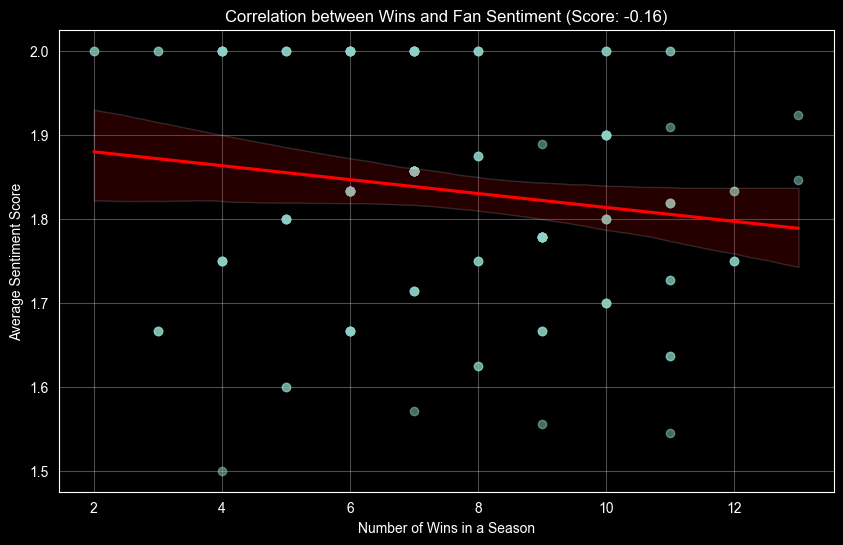

The correlation coefficient is -0.1612


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CREATE SYNTHETIC FAN SENTIMENT DATA
# ==========================================
# We generate synthetic comments based on the 'winner' of each match
positive_lexicon = ['victory', 'champion', 'brilliant', 'outstanding', 'unstoppable', 'masterclass']
negative_lexicon = ['loss', 'poor', 'disappointing', 'weak', 'struggling', 'clueless']

def generate_synthetic_comments(row):
    team = row['winner']
    venue = row['venue']
    # Randomly pick words to create a "fan comment"
    pos_words = np.random.choice(positive_lexicon, size=2)
    comment = f"{team} played a {pos_words[0]} game at {venue}. Truly {pos_words[1]}!"
    return comment

# Apply to a sample or the whole dataframe
df['fan_comment'] = df.apply(generate_synthetic_comments, axis=1)

# ==========================================
# 2. LEXICON-BASED SCORING
# ==========================================
def calculate_sentiment(text):
    text = text.lower()
    pos_score = sum(1 for word in positive_lexicon if word in text)
    neg_score = sum(1 for word in negative_lexicon if word in text)
    return pos_score - neg_score

df['sentiment_score'] = df['fan_comment'].apply(calculate_sentiment)

# ==========================================
# 3. SEASONAL SENTIMENT VS PERFORMANCE
# ==========================================
# Group by Team and Season to compare Sentiment vs Win %
performance_df = df.groupby(['season', 'winner']).agg({
    'sentiment_score': 'mean',
    'id': 'count' # Number of wins
}).reset_index().rename(columns={'winner': 'team', 'id': 'wins'})

# Normalize wins to compare with sentiment
performance_df['win_intensity'] = performance_df.groupby('season')['wins'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# ==========================================
# 4. CORRELATION & VISUALIZATION
# ==========================================
correlation = performance_df['sentiment_score'].corr(performance_df['wins'])

plt.figure(figsize=(10, 6))
sns.regplot(data=performance_df, x='wins', y='sentiment_score',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Correlation between Wins and Fan Sentiment (Score: {correlation:.2f})')
plt.xlabel('Number of Wins in a Season')
plt.ylabel('Average Sentiment Score')
plt.grid(True, alpha=0.3)
plt.show()

print(f"The correlation coefficient is {correlation:.4f}")

# **FEATURES mentioned in questions are high level example. You can create more features to make your model robust **

## 📤 Submission Guidelines

1. Submit a single Jupyter notebook with all solutions
2. Include markdown cells explaining your approach
3. Ensure all code is reproducible
4. Add a summary section with key findings
5. List any assumptions made

## 💡 Tips
- Focus on practical insights over complex models
- Validate all findings with appropriate metrics
- Consider real-world IPL scenarios in your analysis
- Document any data quality issues encountered

---

<div style="background-color: #f0f8ff; padding: 15px; border-radius: 10px; text-align: center;">
<h3>🏆 Good Luck!</h3>
<p>May the best Data Scientist win!</p>
</div>